In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# Exercise 9: Travelling Salesman Problem and Genetic Algorithm

## Helper functions

In [2]:
# ========================================
# Helper function to plot the coordinates
# ========================================

def plot_coords(x_coord, y_coord, coords_type):

    plt.figure(figsize=(5, 5))
    plt.scatter(x_coord, y_coord, color='blue', s=0)
    # Instead of using points to represent cities I put the city index in place of the marker
    for i in range(len(x_coord)):
        plt.text(x_coord[i], y_coord[i], str(i+1), fontsize=10, ha='center', va='center', c="b")
    plt.title('City Coordinates on a ' + coords_type)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')

    if (coords_type == "Square"):
            plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='red', linestyle='--', linewidth=1)

    plt.grid()
    plt.show()

In [3]:
# =====================================
# Helper function to plot the fitness
# =====================================

def plot_fitness(df):

    # Since Rank 0 is always the best individual of the generation, we just filter for Rank == 0
    best_fitness_df = df[df['Rank'] == 0]

    # Calculate the average fitness of the best half of the population
    half_population = max(df['Rank'])/2.0
    ave_fitness_best_half = df[df['Rank'] < half_population].groupby('Generation')['Fitness'].mean()


    plt.figure(figsize=(10, 5))
    plt.plot(ave_fitness_best_half.index, ave_fitness_best_half.values, color='orange', linewidth=2, label='Average Fitness of Top 50%')
    plt.plot(best_fitness_df['Generation'], best_fitness_df['Fitness'], color='purple', linewidth=2, label='Best Individual (Rank 0)', alpha=0.7)
    plt.title('Fitness vs Generation: Best Individual and Average of Top 50%')
    plt.xlabel('Generation')
    plt.ylabel('Tour Length')
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
# ================================
# Helper function to plot a tour
# ================================

def plot_tour(generation_num, df, x_coord, y_coord, dist_type):
    # Extract the row for the best individual of the requested generation
    # .iloc[0] safely grabs the first matching row as a Series
    best_row = df[(df['Generation'] == generation_num) & (df['Rank'] == 0)].iloc[0]
    
    # Extract just the city indices (skipping the first 3 columns: Gen, Rank, Fitness)
    tour = best_row[3:].values.astype(int)
    fitness = best_row['Fitness']
    
    plt.figure(figsize=(5, 5))

    plt.gca().set_aspect('equal', adjustable='datalim')

    plt.scatter(x_coord, y_coord, color='blue', s=0)
    
    # Plot the city numbers
    for i in range(len(x_coord)):
        plt.text(x_coord[i], y_coord[i], str(i + 1), fontsize=8, ha='center', va='center', c="b")

    span_x = max(x_coord) - min(x_coord)
    dynamic_head_size = 0.015 * span_x # Always scales to 1.5% of the data width

    # Connect the cities with arrows
    for i in range(len(tour) - 1):
        city_a = tour[i] - 1      
        city_b = tour[i + 1] - 1  
        
        dx = x_coord[city_b] - x_coord[city_a]
        dy = y_coord[city_b] - y_coord[city_a]
        
        plt.arrow(x_coord[city_a], y_coord[city_a], dx, dy,
                  head_width=dynamic_head_size,        
                  head_length=dynamic_head_size,       
                  fc='green', ec='green',
                  length_includes_head=True,
                  alpha=0.7)              
        
    if (dist_type == "square"):
        plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='red', linestyle='--', linewidth=1)
    
    plt.title(f'Best Tour Visualization: Generation {generation_num}\nFitness: {fitness:.4f}')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid()
    plt.show()

## Theoretical Overview

The aim of this exercise is to solve the Travelling Salesman Problem (TSP) using a Genetic Algorithm (GA). The algorithm will be tested on two different spatial configurations:
* **Circular Distribution:** Cities are uniformly distributed along a circumference. The analytical solution is known, as the shortest route simply connects contiguous cities sequentially. 
* **Square Distribution:** Cities are uniformly distributed inside a square. The optimal route should be as "circular" as possible, avoiding intersecting paths.

### The Travelling Salesman Problem (TSP)
The Travelling Salesman Problem is a classic example of combinatorial optimization. Given a set of $N$ cities, the objective is to find the shortest possible route that visits every city exactly once and returns to the starting point. 

Because the space of solutions is discrete and finite, it is a combinatorial problem. However, the number of possible unique tours for $N \ge 3$ cities scales factorially as $(N-1)!/2$ (accounting for starting city and direction symmetries). Consequently, the TSP belongs to the class of **NP-hard** problems. The objective function (the total length of the tour) possesses a massive number of local minima. For large values of $N$, exact enumerative methods become computationally intractable. Therefore, we must rely on heuristic or stochastic algorithms to find a minimum that, even if not the absolute global optimum, is highly optimized and practically acceptable.

### Genetic Algorithms (GAs)
Genetic Algorithms are metaheuristic optimization techniques inspired by the biological processes of natural selection and genetics, originally formalized by John Holland. Rather than working on a single solution, GAs maintain and evolve a *population* of candidate solutions, utilizing trial, error, and probabilistic transitions to navigate the search space.

GAs differ fundamentally from traditional optimization methods in several ways:
* They work with a coded representation of the parameter set (in this case, a 1D sequence of city indices).
* They search from a population of points simultaneously, allowing for implicit parallelism.
* They use direct fitness evaluations rather than derivatives or auxiliary knowledge.
* They rely on probabilistic, rather than deterministic, transition rules.

#### Biological Analogy and Terminology
GAs map the parameters of an optimization problem to biological concepts:
* **Chromosome (or Individual):** A single candidate solution. In the context of the TSP, a chromosome is a specific 1D array representing the sequence of visited cities.
* **Gene:** An element of the chromosome (a specific position in the sequence).
* **Allele:** The specific value that a gene can take (the actual index of the city at that position).
* **Fitness:** A measure of the "goodness" of an individual. For the TSP, the fitness corresponds to the total length of the tour, which the algorithm seeks to minimize (so it is technically the negative of the fitness).

#### The Evolutionary Engine
The algorithm operates iteratively, creating successive **generations** of solutions through three primary genetic operators:

1.  **Selection:** This operator determines which individuals are allowed to reproduce. The probability of selection is proportional to an individual's fitness, meaning shorter routes have a higher chance of passing their genetic information to the next generation.
2.  **Crossover:** Once two parents are selected, they combine to produce offspring. Crossover exchanges subparts of the two parent chromosomes, recombining good "building blocks" (short, highly fit sub-routes) into potentially better higher-order solutions.
3.  **Mutation:** With a small probability, the genes of an offspring are randomly altered. Mutation is crucial for maintaining genetic diversity within the population and preventing the algorithm from stagnating in local minima.

#### Implementation Strategy
A standard run of a GA initializes a random population, evaluates its fitness, and then repeatedly applies selection, crossover, and mutation to generate a new population until a convergence criterion or a maximum number of generations is met. 

There are different strategies for replacing the population. For this simulation, I have opted for a **Generational GA** with **Elitism**. While the majority of the population is completely replaced by new offspring at each iteration, the single best individual from the previous generation is always carried over untouched. This guarantees that the absolute best route discovered by the algorithm is never accidentally destroyed by crossover or mutation.

## Implementation

### Coordinate Generation (`GenerateCoords.h`)

The geographic initialization of the problem is managed by the `GenerateCoords` class in the `src/GenerateCoords.h` header file. This class is responsible for generating and storing the spatial coordinates of the $N$ cities in a 2D Cartesian plane. Because the map remains constant throughout the evolution of the algorithm, this class is utilized only once during the setup phase at the beginning of the simulation.

The class relies on the Armadillo library for efficient matrix storage and a custom `Random` class for generation.

**Constructor & Key Methods:**

* **`GenerateCoords(int n_cities)`**: The constructor initializes the object by setting the total number of cities, allocating memory for an $N \times 2$ Armadillo matrix (`_coords`), and seeding the random number generator via the shared `InitializeGenerator` utility.
* **`GenCirc()`**: Generates `n_cities` coordinate pairs uniformly distributed along a unit circumference. It extracts a random angle $\theta \in [0, 2\pi)$ for each city and calculates $x = \cos(\theta)$ and $y = \sin(\theta)$. It sets the `_coord_type` attribute to `"circumference"`.
* **`GenSquare()`**: Generates `n_cities` coordinate pairs uniformly distributed inside a square of unit side. It extracts $x, y \in [0, 1)$ for each city. It sets the `_coord_type` attribute to `"square"`.
* **`get_coords_matrix()`**: A getter method that returns the full Armadillo matrix containing all generated $(x, y)$ pairs.
* **`get_coords(int city_index)`**: A safe getter that returns a `std::pair<double, double>` containing the coordinates of a specific city, complete with boundary checking to prevent segmentation faults.
* **`save_coords()`**: Writes the generated coordinates to a data file (e.g., `input/Coords_square.dat` or `input/Coords_circumference.dat`). The file is explicitly written without string headers to ensure seamless parsing by the Armadillo `.load()` function in `src/Initializer.h`.

### Initialization (`Initializer.h`)

All setup and initialization routines are abstracted into the `Initializer.h` header. This file handles parameter parsing, map configuration, and output stream generation.

**1. Configuration Parsing (`ReadInput`)**
The simulation parameters are stored in a simple `Config` struct. The `ReadInput` function reads a formatted text file (`input/input.dat`) word-by-word, mapping string keys to their corresponding values in the struct. The parser automatically stops when it encounters the `ENDINPUT` token, allowing for comments and documentation to be safely written at the bottom of the input file. If an unrecognized key is found, the program safely aborts, preventing silent misconfigurations.

**2. Coordinate Setup (`SetupCoordinates`)**
This function works in two distinct modes controlled by the `GENERATE_COORDS` parameter:
* **Generation Mode (`GENERATE_COORDS True`):** It invokes the `GenerateCoords` class to dynamically create a new set of coordinates based on the requested `COORDS_TYPE` (Circular or Square), saves the newly generated map to the disk, and returns the coordinate matrix.
* **Reading Mode (`GENERATE_COORDS False`):** It bypasses generation and loads pre-existing coordinate maps from the `input/` directory. This is useful when the coordinate have been previously generated and allows for changing only the number of generations or the population size without generating new coordinate every time. Moreover, it is useful when the coordinates are provided in advance such as in the `Italy` configuration, which loads the coordinates of Italian provincial capitals (`cap_prov_ita.dat`). 
* *Dynamic Resizing:* Crucially, when in Reading Mode, the algorithm automatically overwrites the `N_CITIES` configuration parameter with the actual number of rows loaded from the file (`coord_mat.n_rows`). This ensures the simulation adapts dynamically (e.g., automatically scaling to 110 cities for Italy) regardless of the dummy value written in `input.dat`.

3. **Logger Setup (`SetupLoggers`)**
To monitor the simulation without flooding the terminal or overwhelming the hard drive, the initialization handles dual file streams:

* **The Master Log:** A dynamically named file (e.g., `poplog_N34_Pop200_Gen200_Circular.dat`) that records the evolutionary state of the population.

* **The Synthetic Toggle (`USE_SYNTHETIC_LOG`):** To prevent massive file generation during high-population, real-world simulations, the user can toggle a synthetic logging mode via the input file. When enabled, the logger appends a `_synth.dat` suffix and routes the data through the optimized `SavePopulationLogSynth` method.

* **The Summary Report:** A clean, human-readable file (`output.dat`) that stores the simulation metadata and tracks only the best global fitness over time.

By passing the output streams by reference, this function opens the files, writes the necessary headers, and leaves the open pipes ready for the evolutionary engine to stream data efficiently.

### The Individual (`Individual.h` & `Individual.cpp`)

The `Individual` class encapsulates a single candidate solution for the Travelling Salesman Problem. In this context, an individual is represented by a 1D sequence (vector) of city indices and its correspondingly evaluated fitness score. 

To ensure strict data encapsulation and prevent the main loop from accidentally generating malformed solutions, the constructor of this class is `private`. By declaring `friend class Population`, only the `Population` class has the authority to instantiate and initialize an `Individual`.

**Key Responsibilities and Methods:**

* **Validation (`_is_valid()`)**: 
  Before an individual is officially created, the constructor invokes this private method to enforce the strict boundary rules of the TSP. It verifies that:
  1. The tour contains exactly $N+1$ elements.
  2. The tour starts and ends strictly at city index `1` (closing the loop).
  3. No city index is out of bounds.
  4. Every city is visited exactly once (checked via a boolean visitation array).
  If any of these conditions are violated, the program safely aborts, preventing silent genetic corruption.

* **Fitness Computation (`_compute_fitness()`)**: 
  This private method calculates the total length of the tour using the $L^{(1)}$ cost function, defined as the sum of the Euclidean distances between consecutive cities in the sequence:
  $$L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|$$
  *(Note: The sequence is implicitly closed, meaning the final term connects the last city back to the starting city $\vec{x}_1 = \vec{x}_{N+1}$).*

* **Getter Methods**: 
  The class exposes read-only access to its internal state through `get_fitness()`, `get_individual()`, and `get_n_cities()`. This allows the `Population` class to efficiently sort the individuals and extract the sequences of cities for crossover without modifying the underlying objects.

* **Data Export (`save_tour()`)**: 
  A utility method `save_tour(filename)` allows the individual to write its sequence of city indices to an external file. This is particularly useful for tracking the "Best Individual" at the end of the simulation to plot the final optimized route.

### The Evolutionary Engine (`Population.h` & `Population.cpp`)

The `Population` class is the core of the Genetic Algorithm. It encapsulates the entire collective of candidate solutions (`Individual` objects) and drives them through the evolutionary cycle of selection, crossover, and mutation over successive generations.

**1. Initialization and Sorting**
When the `Population` object is instantiated, it generates `pop_size` completely random tours. To achieve this, it uses a custom implementation of the Fisher-Yates shuffle (`GenerateRandomTour`), carefully preserving the first and last city as index `1` to satisfy the TSP boundary conditions. The algorithm works by swapping indices: it iterates backward with an index $i$ from $N_{cities} - 1$ down to $1$. For each iteration, it extracts a random number $r$ uniformly distributed in $[0, 1)$, multiplies it by the current loop index $i$, and truncates it to an integer using a `static_cast`. It then adds 1 to this result to obtain a random target index $j \in [1, i]$, and swaps the elements at $i$ and $j$.

Immediately after creation, the population is sorted in ascending order of tour length, meaning the absolute best individual always resides at `_pop[0]`.

**2. The Selection Operator**
To decide which individuals get to reproduce, the algorithm employs a non-linear, rank-based probabilistic selection method. The algorithm extracts a random number $r \in [0, 1)$ and computes the selected index using a power-law mapping:

$$j = \lfloor N_{pop} \times r^p \rfloor$$

With the exponent set to $p = 3.0$, this function heavily biases the selection toward lower indices (values closer to 0). Given that the population is sorted from shorter (fitter) tours to longer (less fit) tours, this ensures that the fittest individuals are selected much more frequently to become parents, while still leaving a small probability for the worst individuals to reproduce and maintain genetic diversity.

#### Genetic Operators

The algorithms exploration of the solution space relies on one recombination operator (Crossover) and four distinct mutation operators. All operators are strictly designed to preserve the TSP boundary conditions (the tour must always begin and end at city index `1`).

**1. Crossover (Recombination)**
The crossover operator (triggered with a probability $p_c = 0.7$) mimics genetic recombination by merging the DNA of two parent routes to create two offspring. It works as follows:
1. A random cut-point is selected along the 1D array.
2. Child 1 inherits the exact sequence of cities from Parent 1 up to the cut point.
3. The remaining missing cities are appended to Child 1 in the exact order they appear in Parent 2. 
4. The process is mirrored for Child 2 (conserving Parent 2, completing with Parent 1).

If crossover does not occur, the children are exact clones of their parents.

**2. Mutations**
Regardless of whether crossover triggered, each child is independently subjected to four mutation operators, each with a small probability ($p_m = 0.1$):

* **Pair Permutation:** Selects two random positions strictly between $1$ and $N_{cities}-1$ and swaps the cities at those indices.
* **Shift:** Selects a contiguous block of $m$ cities and circularly shifts them to the right by a random amount $n$. 
* **Inversion:** Selects a contiguous sub-array of cities and reverses their visitation order.
* **Block Swap:** Selects two non-overlapping, contiguous blocks of cities of length $m$ and swaps their positions within the tour.

By keeping the mutation rate low, the algorithm prevents the destruction of good solutions while continuously injecting enough genetic diversity to escape local minima.

#### The Evolutionary Engine (`EvolveOneGeneration()`)

The `EvolveOneGeneration()` method inside the `Population` class serves as the core driver of the algorithm. It constructs the next generation of candidate solutions through the following operations:

1. **Elitism:** The function begins by allocating an empty `new_population` vector. To guarantee that the best-optimized route is never lost to destructive mutations, it immediately copies the absolute best individual from the previous generation (residing at `_pop[0]`) into the new vector.
2. **The Breeding Loop:** The engine then enters a `while` loop that continues until the `new_population` reaches the exact specified `_pop_size`. In each iteration, it:
    * **Selects** two parents from the old population using the rank-based `Select()` method.
    * **Recombines** them via the Crossover operator (with probability $p_c = 0.7$) to produce two children. 
    * **Mutates** both children independently, subjecting them to the four distinct mutation operators (each with probability $p_m = 0.1$).
3. **Strict Size Control:** The children are pushed into the new population vector. Because the initial Elitism step occupies one slot, the algorithm safely checks the remaining capacity before adding the second child, discarding it if necessary to ensure the population remains exactly at `_pop_size`.
4. **Generational Replacement:** Once the new generation is fully populated, it completely overwrites the old population (a Generational GA approach). 
5. **Sorting:** Finally, the entire population is re-sorted by fitness, preparing the ranks for the next evolutionary cycle.

#### Data Logging and Export
To facilitate post-simulation data analysis and visualization, the `Population` class includes methods to stream the state of the population to an external log file.

The class handles this through two distinct output modes:

* **Standard Logging (`SavePopulationLog`):** Iterates through the `_pop` vector and writes a single line per individual containing: the Generation Number, the Rank Index (where 0 is the absolute best solution), the Fitness Score (route length), and the complete 1D Genetic Sequence (Tour).

* **Synthetic Logging (`SavePopulationLogSynth`):** An optimized logging alternative. It writes the exact same statistical metadata (Generation, Rank, Fitness) for every individual in the population, but only records the full physical Genetic Sequence for the absolute champion (Rank 0).

By exporting the entire population's metadata, this granular logging structure unlocks comprehensive data analysis, such as calculating the average fitness of the best half of the population to track convergence. The synthetic option ensures we retain 100% of these statistical analysis capabilities without generating prohibitively massive text files during large-scale simulations.

## Observations and Results

This section presents the results of the Genetic Algorithm applied to the Travelling Salesman Problem for $N=34$ cities, evaluated across two distinct spatial topologies: distributed along a unit circumference and scattered randomly within a unit square. 

Through empirical testing of the algorithm's hyperparameters, two significant behavioral patterns emerged:
1. **Population Size over Generations:** Increasing the population size (`POP_SIZE`) exerts a vastly greater influence on successfully discovering the optimal tour than merely increasing the number of generations. A larger population provides the essential genetic diversity required to explore the highly complex solution space effectively.
2. **The Necessity of Elitism:** The inclusion of Elitism proved to be computationally critical. Disabling elitism resulted in drastically slower convergence rates, requiring massively inflated populations to achieve comparable results, as the algorithm frequently lost its best-discovered routes to destructive mutations or unfavorable crossovers.

### Visualization Structure
For both spatial configurations, the subsequent data analysis is structured into three visualizations:

1. **The Atlas:** A standard scatter plot displaying the raw 2D Cartesian coordinates of the 34 cities prior to optimization.
2. **Convergence Tracking:** A plot tracking the $L^{(1)}$ cost function (tour length) as a function of the generation. This graph superimposes the fitness of the **Best Individual** alongside the **Average Fitness of the best 50%** of the population. This comparison serves as a crucial diagnostic metric: a tight correlation between the two curves demonstrates robust, collective genetic convergence. Conversely, a severe mismatch would imply that the champion is merely an isolated "lucky mutant" while the broader population remains trapped in highly sub-optimal states—a scenario we actively want to avoid.
3. **Tour Evolution:** A comparative sequence of spatial plots tracing the shortest discovered path at three critical stages of the simulation. To visually demonstrate the algorithm's optimization process, this section maps the route from its initial, completely random configuration (Generation 0), through an intermediate state of partial convergence, to the final optimized closed loop.

### Circular Coordinates Results

For the circular distribution, the cities were uniformly placed along the perimeter of a unit circle. The analytical solution for this configuration is trivial: the shortest possible path simply connects adjacent cities sequentially along the circumference. This provides a perfect benchmark to verify the correctness of the algorithm.

The simulation was executed with the following configuration:
* **Number of Cities ($N$):** 34
* **Population Size:** 200
* **Generations:** 200

In [22]:
df_circ = pd.read_csv("outputs/poplog_N34_Pop200_Gen200_Circular_synth.dat", sep=r'\s+', comment='#')

#### City coordinates

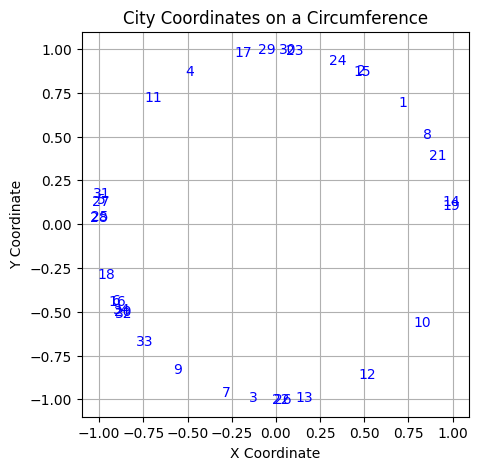

In [23]:
x_coord, y_coord = np.loadtxt("input/Coords_circumference" + ".dat", unpack=True)
plot_coords(x_coord, y_coord, "Circumference")

#### Fitness VS Generation

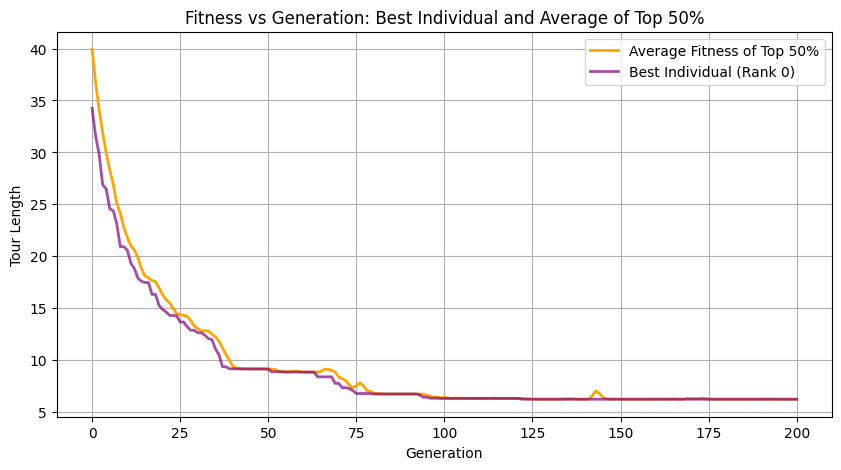

In [24]:
plot_fitness(df_circ)

#### Tour plotting

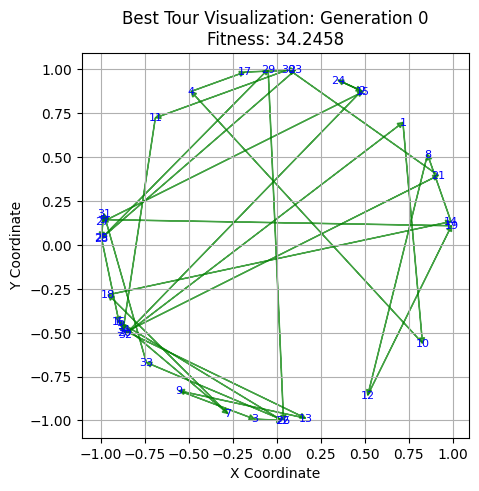

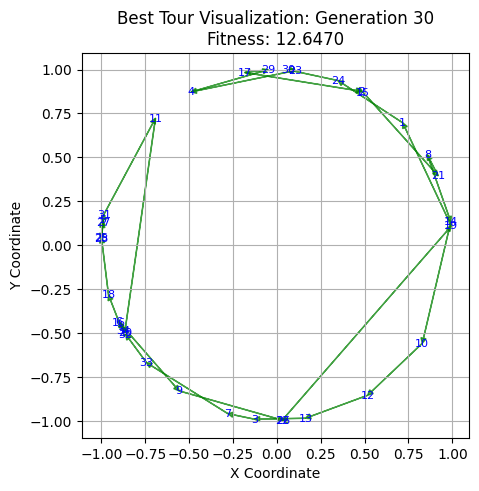

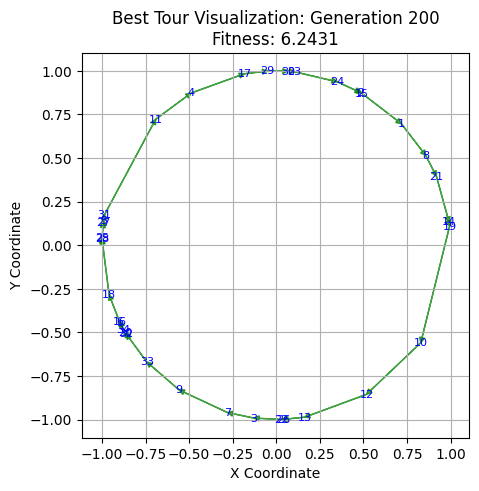

In [25]:
plot_tour(0, df_circ, x_coord, y_coord, "circumference")
plot_tour(30, df_circ, x_coord, y_coord, "circumference")
plot_tour(200, df_circ, x_coord, y_coord, "circumference")

### Square Uniform Distribution Results

For the square distribution, the cities were uniformly placed inside the area of a square of unit side. The analytical solution for this configuration is not as trivial as in the circular case: one should expect that the best tour would be "as circular as possible".

The simulation was executed with the following configuration:
* **Number of Cities ($N$):** 34
* **Population Size:** 200
* **Generations:** 200

In [26]:
df_square = pd.read_csv("outputs/poplog_N34_Pop200_Gen200_Square_synth.dat", sep=r'\s+', comment='#')

#### City coordinates

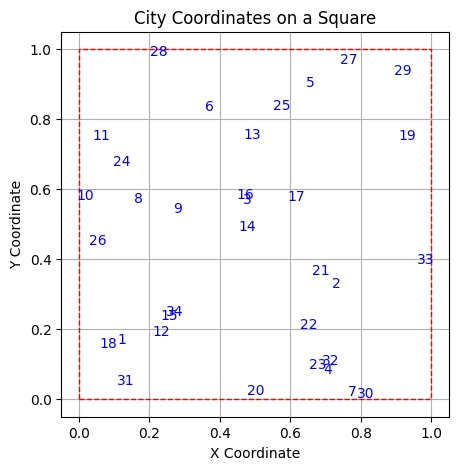

In [27]:
x_coord, y_coord = np.loadtxt("input/Coords_square.dat", unpack=True)
plot_coords(x_coord, y_coord, "Square")

#### Fitness VS Generation

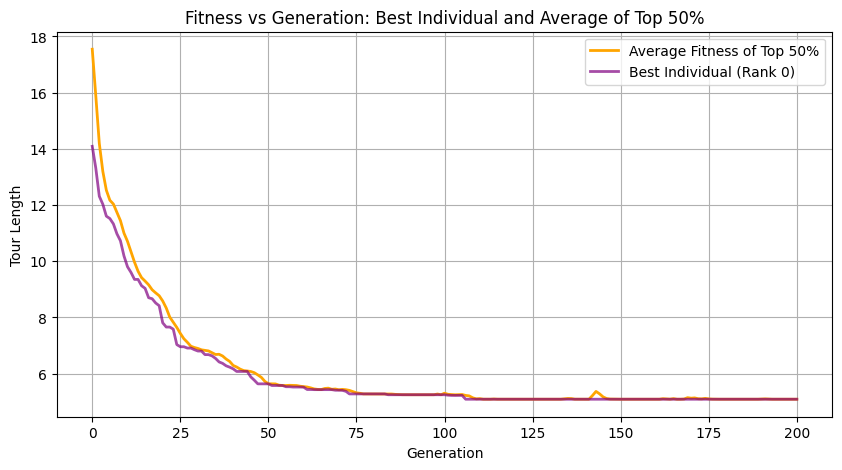

In [28]:
plot_fitness(df_square)

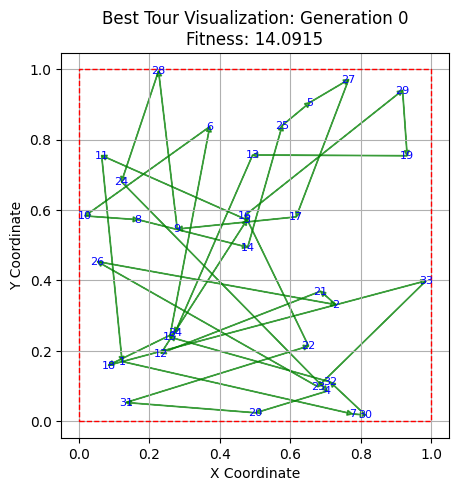

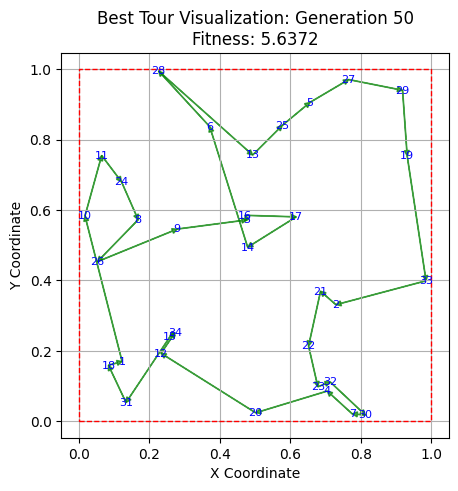

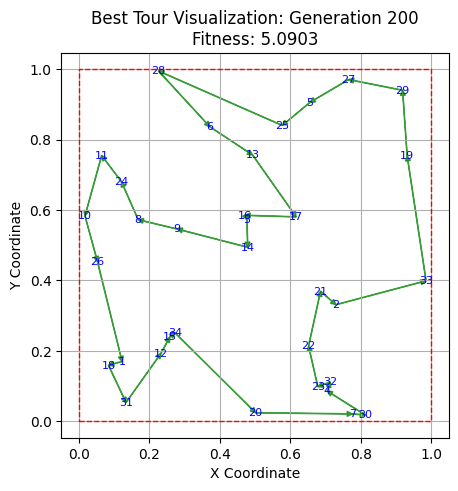

In [29]:
plot_tour(0, df_square, x_coord, y_coord, "square")
plot_tour(50, df_square, x_coord, y_coord, "square")
plot_tour(200, df_square, x_coord, y_coord, "square")

### Application to Real-World Data: Italian Provincial Capitals

When applied to the realistic geographical distribution of the Italian provincial capitals, the sequential Genetic Algorithm demonstrates excellent optimization capabilities. Operating with a population size of $N_{pop} = 700$ over $2000$ generations, the evolutionary engine successfully converges to a well optimized tour.

However, while the sequential GA is capable of achieving these optimal geometric results, doing so reveals a major computational bottleneck regarding execution time. Processing a large population through selection, crossover, mutation, and fitness evaluations across hundreds of generations on a single thread requires substantial CPU time. 

This establishes the baseline for **Laboratory 10**. The next objective is not to improve the algorithmic accuracy, but to optimize the performance with a parallelized architecture to distribute the computational workload across multiple processing nodes.

_**Note on Large Data Files:** The output log containing the complete evolutionary history of the Italian provincial capitals `outputs/poplog_N110_Pop700_Gen2000_Italy.dat` exceeds GitHub's file size limit and is deliberately excluded from this repository. If you wish to verify the real-world map results, you can easily reproduce them locally by running the code; the exact parameters required for this simulation are already configured as the default in `inputs/input.dat`._
_A second file `outputs/poplog_N110_Pop700_Gen2000_Italy_synth.dat` is stored in the repository, containing only the essential data for the data analysis: Generation, Rank, Fitness and the absolute best tour for each generation. This allows for the visualization of the essential results without clogging the repository._

In [38]:
df_italy = pd.read_csv("outputs/poplog_N110_Pop700_Gen2000_Italy_synth.dat", sep=r'\s+', comment='#')

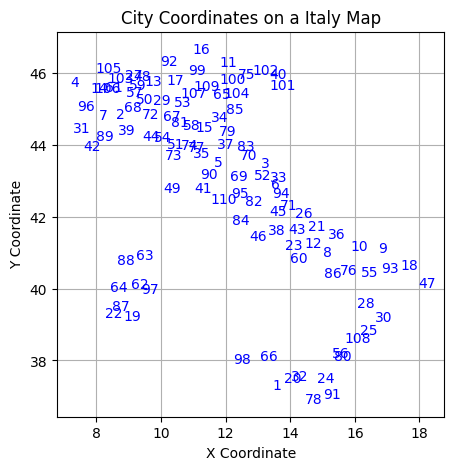

In [39]:
x_coord, y_coord = np.loadtxt("input/cap_prov_ita.dat", unpack=True)
plot_coords(x_coord, y_coord, "Italy Map")

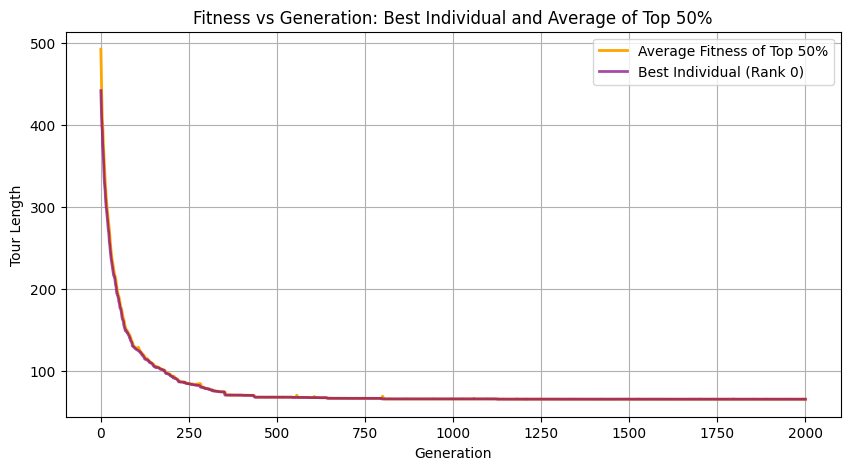

In [40]:
plot_fitness(df_italy)

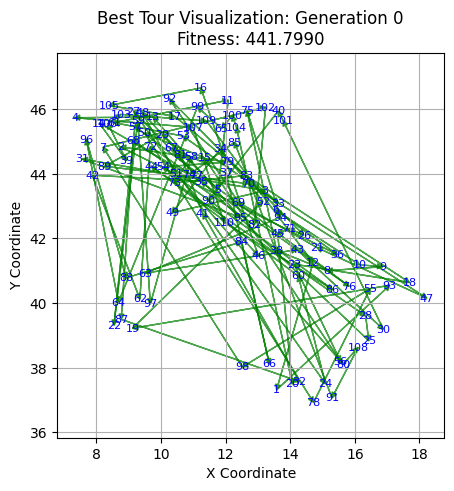

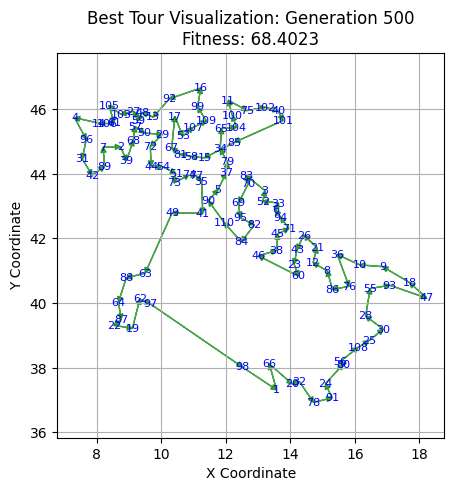

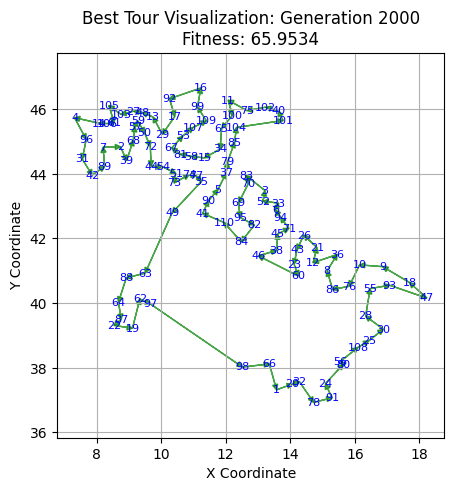

In [44]:
plot_tour(0, df_italy, x_coord, y_coord, "italy")
plot_tour(500, df_italy, x_coord, y_coord, "italy")
plot_tour(2000, df_italy, x_coord, y_coord, "italy")

## Results to compare with notebook 10

The previous cells demonstrate that the sequential algorithm successfully finds a highly optimized path when utilizing a large population of 700 individuals. To establish a baseline for comparison with the parallelized Island Model in Laboratory 10, the sequential algorithm was re-run with severely restricted resources: a population of only 100 individuals over 2000 generations. The results, plotted below, show that while the algorithm still converges, the final route is significantly poorer compared to the robust 700-individual run. This "starved" sequential run will serve as our standard benchmark for evaluating the efficiency of parallel migration.

In [42]:
df_italy_comparison = pd.read_csv("outputs/poplog_N110_Pop100_Gen2000_Italy_synth.dat", sep=r'\s+', comment='#')

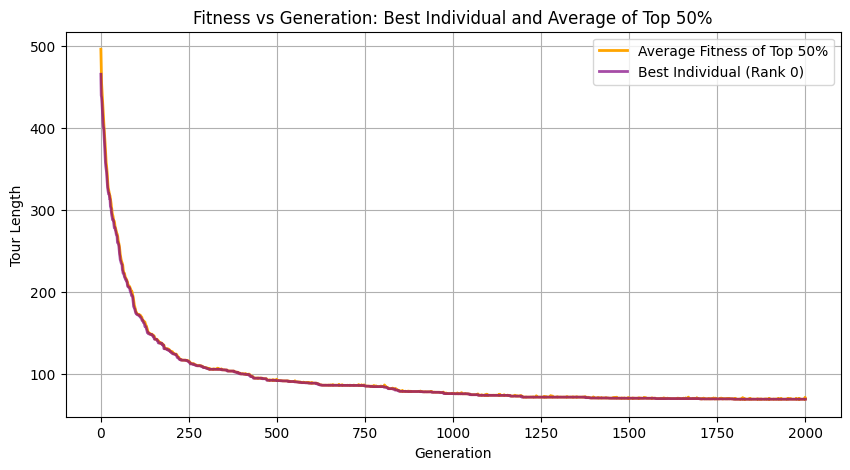

In [45]:
plot_fitness(df_italy_comparison)

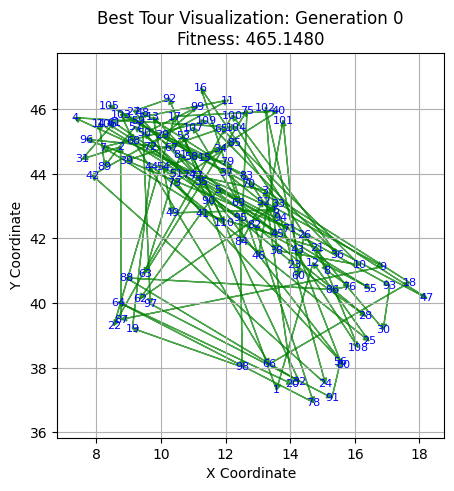

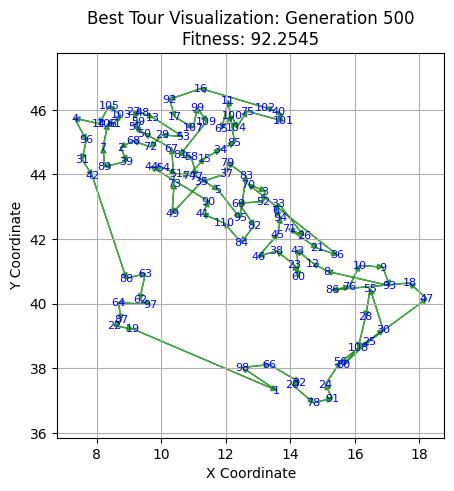

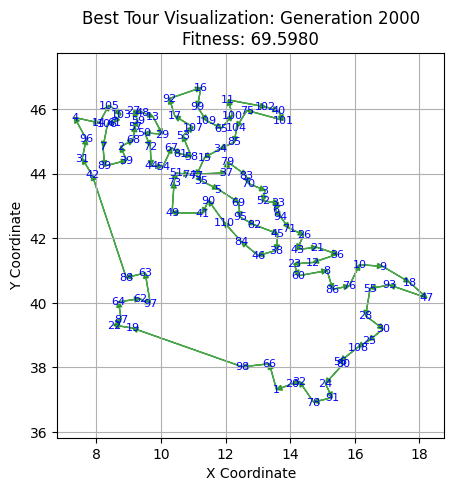

In [46]:
plot_tour(0, df_italy_comparison, x_coord, y_coord, "italy")
plot_tour(500, df_italy_comparison, x_coord, y_coord, "italy")
plot_tour(2000, df_italy_comparison, x_coord, y_coord, "italy")